In [ ]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
from MIST.preprocess import preprocess, construct_gated_interaction
from MIST.MIST import MIST
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 

2026-01-31 21:16:52.262360: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 21:16:52.448615: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-31 21:16:52.448652: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-01-31 21:16:52.486673: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-31 21:16:53.232612: W tensorflow/stream_executor/pla

In [2]:
# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

import rpy2

In [3]:
# the number of clusters
n_clusters = 5

In [4]:
dataset = '151671'

In [ ]:
# read data
file_fold = '/root/workspace/MIST/DLPFC' + str(dataset) #please replace 'file_fold' with the download path
adata = sc.read_visium(file_fold, count_file='filtered_feature_bc_matrix.h5', load_images=True)
adata.var_names_make_unique()

/opt/conda/envs/DSSMST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/envs/DSSMST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata

AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [ ]:

from MIST.preprocess import fix_seed
GLOBAL_SEED = 42

preprocess(adata, n_top_genes=2000,seed=GLOBAL_SEED) 

construct_gated_interaction(adata, n_neighbors_list=[5, 12, 25])

model = MIST(adata, epochs=1200,warmup_epochs=400,beta=0.5, lamda=30,alpha=1,num_scales=3,seed=GLOBAL_SEED)
adata = model.train(n_clusters=5)

adata = model.process(n_clusters=5, refinement=True,radius=15)

Building Scale 0 (K=5) with Soft-Weights...
Building Scale 1 (K=12) with Soft-Weights...
Building Scale 2 (K=25) with Soft-Weights...


/opt/conda/envs/DSSMST/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loss: 0.5791: 100%|██████████| 1200/1200 [00:38<00:00, 31.05it/s]
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.0
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
'Mclust' model object: (EEE,5) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   



In [8]:
adata

AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'mclust', 'domain'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'log1p', 'pca'
    obsm: 'spatial', 'X_pca', 'feat', 'spatial_norm', 'feat_a', 'adj_scale_0', 'adj_scale_1', 'adj_scale_2', 'emb', 'emb_pca'
    varm: 'PCs'

In [9]:
adata.obsm['emb']

array([[ 1.9970506 , -0.16341338, -0.5887007 , ...,  1.6134797 ,
        -0.3500975 ,  0.1507849 ],
       [ 2.5753894 ,  2.141625  , -0.29018772, ...,  0.7574071 ,
         0.57729447,  1.7546405 ],
       [ 0.31951118, -0.3354339 , -0.03172638, ..., -0.78063166,
        -0.03850098, -0.12051985],
       ...,
       [ 1.2676198 ,  0.61438936, -0.14020398, ...,  0.5916414 ,
        -0.08325953,  0.9208282 ],
       [-0.8875027 , -0.08928958,  3.9722974 , ...,  1.3043497 ,
         4.3535185 ,  0.8183603 ],
       [-0.19621588, -0.49808162, -0.26667148, ..., -0.5592639 ,
        -0.23862126,  0.0714272 ]], dtype=float32)

In [ ]:
# add ground_truth
df_meta = pd.read_csv(file_fold + '/metadata.tsv', sep='\t')
df_meta_layer = df_meta['layer_guess']
adata.obs['ground_truth'] = df_meta_layer.values
adata = adata[~pd.isnull(adata.obs['ground_truth'])].copy() 
# calculate metric ARI
ARI = metrics.adjusted_rand_score( adata.obs['ground_truth'] ,adata.obs['domain'])
adata.uns['ARI'] = ARI

print('Dataset:', dataset)
print('ARI:', ARI)

Dataset: 151671
ARI: 0.8338193796380206


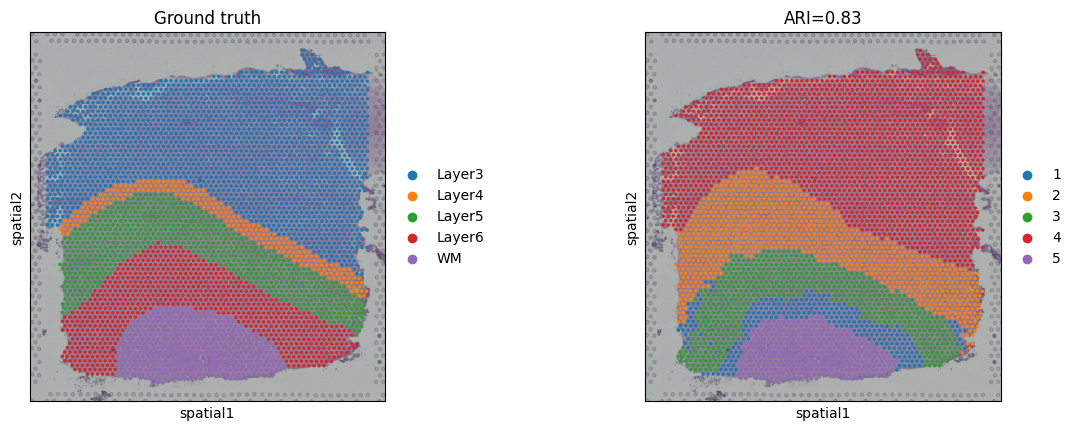

In [11]:
# plotting spatial clustering result
sc.pl.spatial(adata,
              img_key="hires",
              color=["ground_truth", "domain"],
              title=["Ground truth", "ARI=%.2f"%ARI],
              show=True)